# Dataset analysis (Sports_and_Outdoors)

In [49]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## 1. Read .inter file

In [50]:
df = pd.read_csv('../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.inter', sep='\t')

df.head(5)

,user_id:token,item_id:token,rating:float,timestamp:float
0,0,0,5.0,1390694400
1,1,0,5.0,1328140800
2,2,0,4.0,1330387200
3,3,0,4.0,1328400000
4,4,0,4.0,1366675200


## 2. K-core filtering

In [51]:
while True:
    shp = df.shape

    df = df.groupby("user_id:token").filter(lambda x: len(x) >= 5)
    df = df.groupby("item_id:token").filter(lambda x: len(x) >= 5)

    if df.shape == shp:
        break

    print(f"Number of unique items: {df['item_id:token'].nunique()}")
    print(f"Number of unique users: {df['user_id:token'].nunique()}")
    print(df.shape)

## 3. Analysis

### 3.1 Number of unique users & items

In [52]:
print(f"Number of unique items: {df['item_id:token'].nunique()}")
print(f"Number of unique users: {df['user_id:token'].nunique()}")
print(f"Number of unique reviews: {df.shape[0]}")

Number of unique items: 18357
Number of unique users: 35598
Number of unique reviews: 296337


### 3.2 Averages

In [53]:
print(f"Average rating: {df['rating:float'].sum() / df.shape[0]}")
print(f"Average interaction of user: {df.shape[0] / df['user_id:token'].nunique()}")
print(f"Average interaction of item: {df.shape[0] / df['item_id:token'].nunique()}")

Average rating: 4.393450699710128
Average interaction of user: 8.324540704533963
Average interaction of item: 16.142997221768262


### 3.3 Interaction matrix sparsity

In [54]:
print(f"Matrix sparsity: {(1.0 - (df.shape[0] / (df['item_id:token'].nunique() * df['user_id:token'].nunique())))*100}%")

Matrix sparsity: 99.95465195454304%


### 3.4 Top 10 reviewers

In [55]:
user_counts = df.groupby("user_id:token").size().reset_index(name="review_count")
user_counts.sort_values('review_count', ascending=False).head(10)

,user_id:token,review_count
571,571,296
1790,1790,142
737,737,139
2465,2465,115
1697,1697,103
501,501,100
4709,4709,97
184,184,96
3616,3616,94
278,278,92


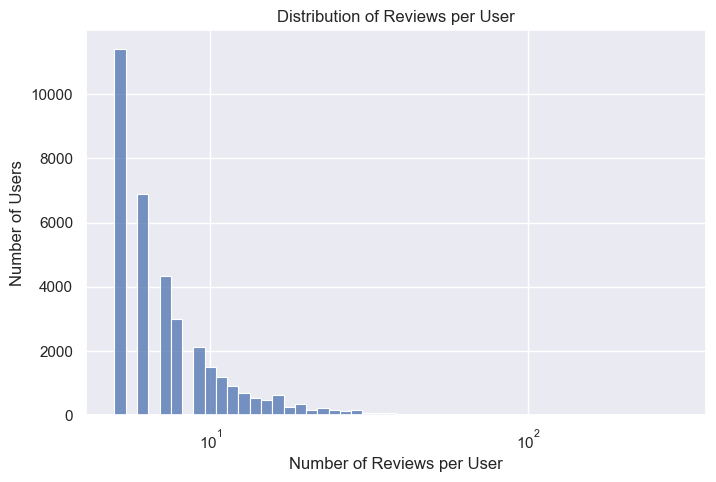

In [56]:
plt.figure(num=0, figsize=(8, 5))
sns.set_theme(style="darkgrid")

sns.histplot(
    user_counts['review_count'], 
    bins=50, log_scale=True
)

plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Reviews per User")

plt.show()

### 3.5 Top 10 reviewed items

In [57]:
product_counts = df.groupby(["item_id:token"]).size().reset_index(name="review_count")
product_counts.sort_values(by="review_count", ascending=False).head(10)

,item_id:token,review_count
7101,7101,1042
7950,7950,763
4068,4068,647
4786,4786,513
248,248,427
9735,9735,401
9250,9250,398
2455,2455,393
7102,7102,372
10057,10057,359


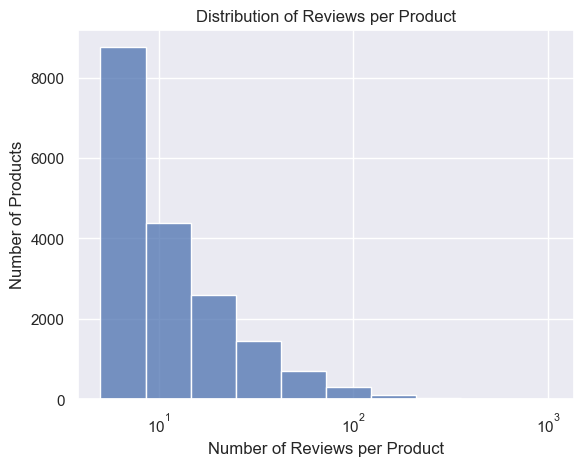

In [58]:
plt.figure(num=1)
sns.set_theme(style="darkgrid")

sns.histplot(
    data=product_counts['review_count'], 
    bins=10,
    log_scale=True
)

plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Distribution of Reviews per Product")

plt.show()

### 3.6 Item lifespan

In [59]:
lifespan_df = df.groupby(by='item_id:token')['timestamp:float'].agg(['min', 'max'])
lifespan_df['max'] = pd.to_datetime(lifespan_df['max'], unit='s')
lifespan_df['min'] = pd.to_datetime(lifespan_df['min'], unit='s')

lifespan_df['lifespan'] = lifespan_df['max'] - lifespan_df['min']
lifespan_df['lifespan'] = lifespan_df['lifespan'].dt.days

lifespan_df = lifespan_df[lifespan_df['lifespan'] != 0]
lifespan_df.head(5)

,min,max,lifespan
item_id:token,,,
0,2012-02-02,2014-06-10,859
1,2013-05-27,2014-05-07,345
2,2013-03-09,2014-07-06,484
3,2011-03-24,2014-07-09,1203
4,2012-11-06,2014-05-10,550


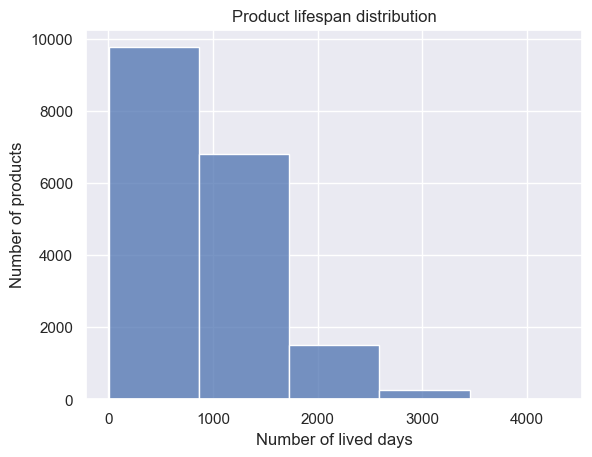

In [60]:
plt.figure(num=3)
sns.histplot(
    lifespan_df['lifespan'],
    log_scale=False,
    bins=5
)
plt.xlabel("Number of lived days")
plt.ylabel("Number of products")
plt.title("Product lifespan distribution")
plt.show()

### 3.7 Seasonality of items

In [61]:
seasonality_df = df.copy()
seasonality_df['timestamp:float'] = pd.to_datetime(seasonality_df['timestamp:float'], unit='s')
seasonality_df.set_index('timestamp:float', inplace=True)
seasonality_df.head()

,user_id:token,item_id:token,rating:float
timestamp:float,,,
2014-01-26,0,0,5.0
2012-02-02,1,0,5.0
2012-02-28,2,0,4.0
2012-02-05,3,0,4.0
2013-04-23,4,0,4.0


In [62]:
seasonality_df['verified_purchase'] = [True for _ in range(seasonality_df.shape[0])]
monthly_transaction_count = seasonality_df['verified_purchase'].resample('MS').count().reset_index(name="purchase_count")
monthly_transaction_count.head(10)

,timestamp:float,purchase_count
0,2002-03-01,1
1,2002-04-01,0
2,2002-05-01,0
3,2002-06-01,0
4,2002-07-01,0
5,2002-08-01,0
6,2002-09-01,2
7,2002-10-01,0
8,2002-11-01,1
9,2002-12-01,0


In [63]:
monthly_transaction_count.sort_values(by='purchase_count', ascending=False).head(20)

,timestamp:float,purchase_count
142,2014-01-01,13621
141,2013-12-01,13020
144,2014-03-01,12310
143,2014-02-01,11775
130,2013-01-01,11668
134,2013-05-01,11591
132,2013-03-01,11587
140,2013-11-01,11339
137,2013-08-01,11322
133,2013-04-01,11127


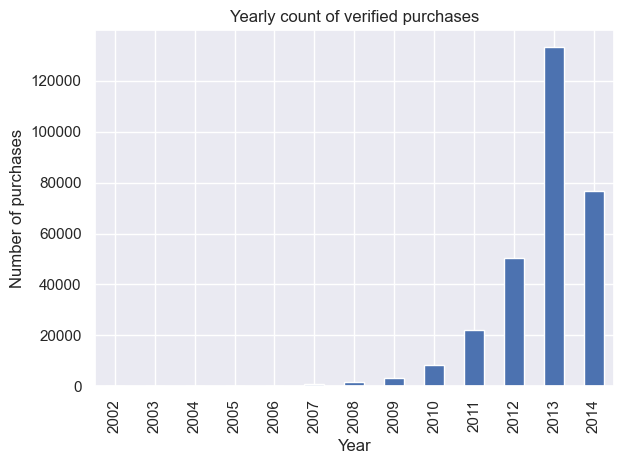

In [64]:
plt.figure(num=4)
yearly_transaction_count = monthly_transaction_count.groupby(monthly_transaction_count['timestamp:float'].dt.year)['purchase_count'].sum()
yearly_transaction_count.plot(kind='bar', title="Yearly count of verified purchases")
plt.xlabel('Year')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.grid(True)
plt.show()

In [65]:
month_subseries_count = monthly_transaction_count.copy()
month_subseries_count['month'] = month_subseries_count['timestamp:float'].dt.month

foo = month_subseries_count.groupby(by='month')['purchase_count'].sum().reset_index(name='purchase_count')
foo.head(12)

,month,purchase_count
0,1,30349
1,2,26524
2,3,29154
3,4,27373
4,5,27507
5,6,27030
6,7,25649
7,8,18555
8,9,17179
9,10,18232


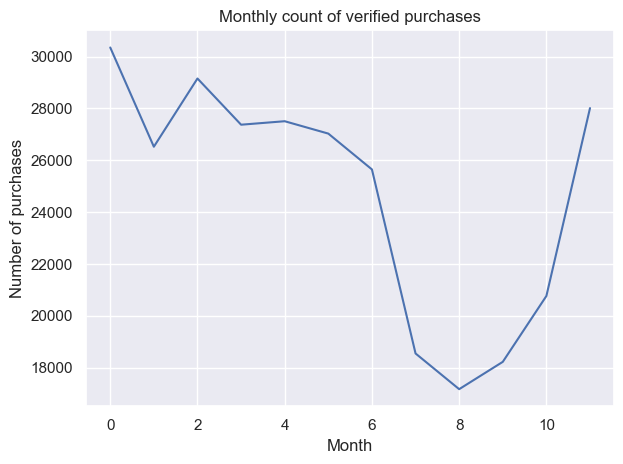

In [66]:
plt.figure(num=5)
foo['purchase_count'].plot(title="Monthly count of verified purchases")
plt.xlabel('Month')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.grid(True)
plt.show()

In [67]:
rating_counts = df['rating:float'].value_counts().sort_index()
rating_counts.head()

rating:float
1.0      9045
2.0     10204
3.0     24071
4.0     64809
5.0    188208
Name: count, dtype: int64

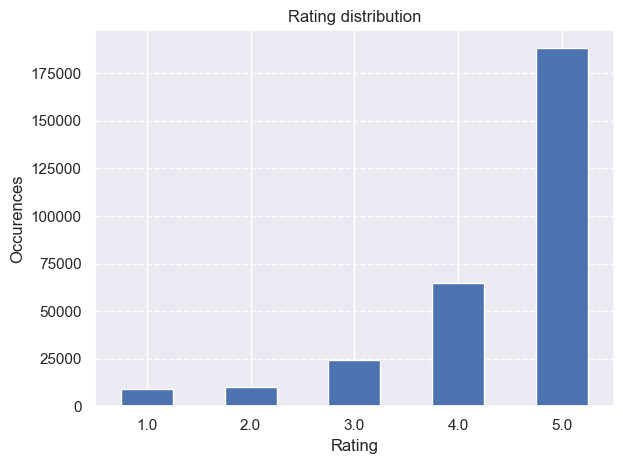

In [68]:
plt.figure(num=6)
rating_counts.plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Occurences')
plt.title('Rating distribution')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### 3.8 Subclasses

In [69]:
df2 = pd.read_csv('../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df2.head(3)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,0,Ghost Inc Glock Armorers Tool 3/32 Punch,9.99,Ghost,"'Sports & Outdoors', 'Hunting', 'Hunting & Fis...",Sports &amp; Outdoors,532941.0
1,1,5 LED Bicycle Rear Tail Red Bike Torch Laser B...,8.26,NaN,"'Lights & Reflectors', 'Sports & Outdoors', 'C...",Toys & Games,15617.0
2,3,Black Mountain Products Resistance Band Set wi...,32.99,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0


In [70]:
subcategories_df = df2.dropna(subset=['categories:token_seq'])
subcategories_df.head(3)
subcategories_df['categories:token_seq'] = subcategories_df['categories:token_seq'].apply(lambda x: x.split(',')[1] if len(x.split(',')) > 1 else x.split(',')[0])
unique_parent_asins_in_subcategory = subcategories_df[['item_id:token', 'categories:token_seq']].drop_duplicates()
product_count_by_subcategory = unique_parent_asins_in_subcategory.groupby('categories:token_seq')['item_id:token'].count().sort_values(ascending=False)

In [71]:
product_count_by_subcategory.head(5)

categories:token_seq
'Sports & Outdoors'    4762
'Hunting'              3859
'Cycling'              1030
'Gun Holsters           808
'Knives & Tools'        607
Name: item_id:token, dtype: int64

In [72]:
top_n_subcategories = product_count_by_subcategory.head(20)
others_count = product_count_by_subcategory.iloc[20:].sum()

if others_count > 0:
    top_n_subcategories['Other'] = others_count

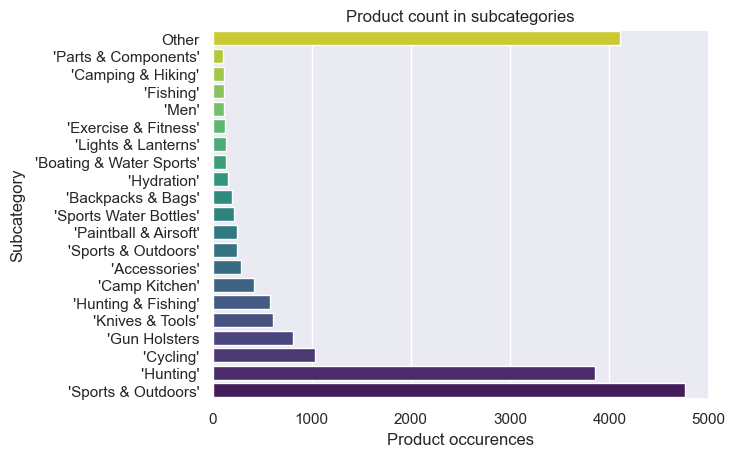

In [73]:
barplot = sns.barplot(x=top_n_subcategories.values, y=top_n_subcategories.index, palette="viridis", hue=top_n_subcategories.index, dodge=False, legend=False)
plt.xlabel('Product occurences')
plt.ylabel('Subcategory')
plt.title(f'Product count in subcategories')
plt.gca().invert_yaxis()